In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib as mpl

### Preparation

##### Set Labels and Colors for CDR methods, MRV topics, and research methods

In [54]:
mrv_topic_colors = {
    'Quantification': '#7da7b8',   # darker bluish-grey
    'Monitoring': '#8dc39f',        # stronger soft green
    'Quality': '#c76a85',           # berry red
    'Governance': '#b39bc8',        # stronger lavender
    'Reporting': '#e1a6b8',         # stronger soft pink
    'Verification': '#a8a8a8',      # medium grey
    'External Impacts': '#d0c97b',   # stronger soft yellow
    'General MRV': '#e5b138',      # muted yellow
    
}

# Define the custom color scheme for each CDR group
cdr_group_colors = {
    "Geochemical CDR": '#C1A28A' ,  # brown for Geochemical CDR
    "Biogenic CDR": '#8fbc8f',      # green for Forestry
    "Synthetic CDR": '#ff7f00',            # orange for CCS
    "General CDR/Other": '#e5e5e5', # grey for General/Other
}  

cdr_method_colors = {
    
    'SCS': '#a47551', 
    
    'A/R': '#238b45', 
    'General forestry': '#66c2a4', 
    'Agroforestry': '#b2e2e2', 
    'Forest management': '#edf8fb',

    'Biochar': '#ce1256',
    'Restoration of landscapes and peats': '#df65b0',
    'EW': '#d7b5d8', 
  
    'OAE': '#016c59', 
    'OIF/AU': '#1c9099', 
    'DOC': '#67a9cf',
    'Algae ': '#bdc9e1', 
    'Blue carbon': '#f6eff7',
       
    'CCS': '#e31a1c',
    'BECCS': '#fd8d3c', 
    'DACCS': '#fecc5c',
    'CCUS': '#ffffb2', 
    
    'General CDR': '#525252',
    'Other': '#969696',    
}


In [55]:
cdr_methods = [
 'SCS',
 'A/R',
 'General forestry',
 'Agroforestry',
 'Forest management',
 'Biochar',
 'Restoration of landscapes and peats',
 'EW',
 'OAE',
 'OIF/AU',
 'DOC',
 'Algae ',
 'Blue carbon',
 'CCS',
 'BECCS',
 'DACCS',
 'CCUS',
 'General CDR',
 'Other'
] 

cdr_method_label = \
{
    'SCS': "Soil Carbon Sequestration",
    'A/R': "Afforestation/Reforestation",
    'General forestry': "General Forestry",
    'Agroforestry': "Agroforestry",
    'Forest management': "Forest Management",
    'Biochar': "Biochar",
    'Restoration of landscapes and peats': "Restoration of Landscapes/Peats",
    'EW': "Enhanced Weathering",
    'OAE': "Ocean Alkalinity Enhancement",
    'OIF/AU': "Ocean Iron Fertilization", 
    'DOC':"Direct Ocean Capture",
    'Algae ':"Algae",
    'Blue carbon': "Blue Carbon",
    'CCS':"CCS",
    'BECCS':"BECCS",
    'DACCS':"DACCS",
    'CCUS':"CCUS",
    'General CDR':"General CDR",
    'Other':"Other"
}      

cdr_group_mapping = {
    
    # Biogenic CDR
    "General forestry": "Biogenic CDR",
    "A/R": "Biogenic CDR",
    "Agroforestry": "Biogenic CDR",
    "Forest management": "Biogenic CDR",
    "SCS": "Biogenic CDR",
    "BECCS": "Biogenic CDR",
    "Biochar": "Biogenic CDR",
    "Restoration of landscapes and peats": "Biogenic CDR",
    "OIF/AU":"Biogenic CDR",
    "Blue carbon": "Biogenic CDR",
    "Algae ": "Biogenic CDR",

    # Geochemical CDR
    "EW": "Geochemical CDR",
    "OAE": "Geochemical CDR",
    
    # Synthetic CDR
    "DACCS": "Synthetic CDR",
    "CCUS": "Synthetic CDR",
    "CCS": "Synthetic CDR",
    "DOC": "Synthetic CDR", 
    
    # General CDR/Other group
    "General CDR": "General CDR/Other",
    "Other": "General CDR/Other"
}


### Read and clean data

In [56]:
df = pd.read_excel("MRVdata_1308.xlsx") 
df_filtered = df[df['Year'] != 2024]
df_included = df_filtered[df_filtered['Inclusion/exclusion'] == 'Inclusion'].copy()

### additonal data

def extract_CDR_method_focus(row):
    CDR_method = []
    CDR_focus = []
    
    for column in cdr_methods:  # previously defined list with columns that contain CDR methods
        if row[column] > 0:
            CDR_method.append(column)
            CDR_focus.append(row[column])
    
    return [CDR_method, CDR_focus]
# add new columns to the data frame
df_included['CDR_focus'] = df_included.apply(lambda row: extract_CDR_method_focus(row), axis=1)
df_included['CDR_method'] = df_included.CDR_focus.str[0]
df_included['CDR_focus'] = df_included.CDR_focus.str[1]


#add new column for MRV topic and study focus to the dataset
def extract_MRV_topic_focus(row):
    MRV_topic = []
    MRV_focus = []
    
    for column in mrv_topic_colors.keys():  # previously defined list with columns that contain MRV topics
        if row[column] > 0:
            MRV_topic.append(column)
            MRV_focus.append(row[column])
    
    return [MRV_topic, MRV_focus]
# add new columns to the data frame
df_included['MRV_focus'] = df_included.apply(lambda row: extract_MRV_topic_focus(row), axis=1)
df_included['MRV_topic'] = df_included.MRV_focus.str[0]
df_included['MRV_focus'] = df_included.MRV_focus.str[1]


# create a dictionary for the assignment of countries to continents
continent_data = pd.read_excel('continents.xlsx')
country_to_continent = dict(zip(continent_data['Country'], continent_data['Continent']))

# Function to determine the continent based on the country
def get_continent(study_location, continent_column): #part of the function, not column names of the df; will be defined later when function is applied
    if pd.isna(study_location):
        return "Not specified"
    if study_location == "Multiple countries":
        return continent_column  # uses the manually definied continents for the category "Multiple countries"
    return country_to_continent.get(study_location.strip(), "Not specified")  # Search for the country in the dictionary and return the continent or 'not specified'

# apply function to df_included
df_included['Study location_continent'] = df_included.apply(
    lambda row: get_continent(row['Study location'], row['Study location: Continent']),
    axis=1
)

### explode
# explode CDR method and focus
df_CDRexplode = df_included.explode(['CDR_method', 'CDR_focus'])
df_CDRexplode["CDR_group"] = df_CDRexplode.CDR_method.replace(cdr_group_mapping)

# explode MRV topic and focus
df_MRVexplode = df_included.explode(['MRV_topic', 'MRV_focus'])

# only quantification studies
df_quant = df_MRVexplode.loc[df_MRVexplode.MRV_topic.isin(["Quantification"])].copy()
df_quant_CDRex = df_quant.explode(["CDR_method"])
df_quant_CDRex["CDR_group"] = df_quant_CDRex.CDR_method.replace(cdr_group_mapping)

# Set the order of continents to be shown on the x-axis
location_order = ['Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania', 'USA', 'China', 'Global', 'Not specified']  

In [57]:
#df_quant.loc[df_quant["Study location"]=="Multiple countries", ""]

### Only quantification studies

### Panel A: Absolute Numbers

In [58]:
# Convert the Study location_continent column to a categorical type with the specified order
df_quant['Study location_continent'] = pd.Categorical(
    df_quant['Study location_continent'],
    categories=location_order,
    ordered=True
)

C:\Users\leonst\AppData\Local\Temp\ipykernel_57604\3977391672.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_size = df_quant.groupby("Study location_continent",as_index=False).size().rename(columns={"size":"total_size"})


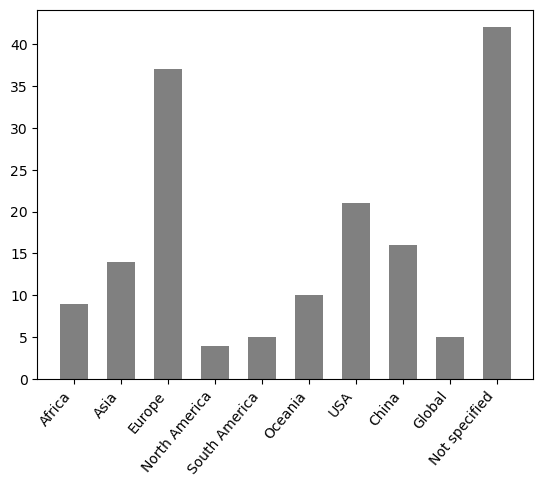

In [59]:
loc_size = df_quant.groupby("Study location_continent",as_index=False).size().rename(columns={"size":"total_size"})

fig, ax = plt.subplots()
width=0.6

ax.bar(loc_size["Study location_continent"], loc_size["total_size"], width, color="grey")
_=ax.set_xticks([i for i in range(len(location_order))], location_order, rotation=50, ha="right")

### Panel B: Shares

In [60]:
locs_cdr_total = df_quant_CDRex.groupby(['Study location_continent'],as_index=False).size().rename(columns={"size":"total_size"}) 
loc_meth = df_quant_CDRex.groupby(['Study location_continent', 'CDR_method'],as_index=False).size() 
for m in loc_meth["CDR_method"].unique():
    for l in location_order:
        if loc_meth.loc[(loc_meth.CDR_method==m)&(loc_meth["Study location_continent"]==l)].shape[0]==0:
                one_row = pd.DataFrame({'CDR_method': [m], 'Study location_continent': [l], 'size': [0]})
                loc_meth = pd.concat([loc_meth, one_row])
loc_meth = loc_meth.merge(locs_cdr_total, on="Study location_continent")
loc_meth["rel"] = loc_meth["size"]/loc_meth["total_size"]

loc_meth["col"] = loc_meth.CDR_method.replace(cdr_method_colors)

loc_meth['Study location_continent'] = pd.Categorical(
    loc_meth['Study location_continent'],
    categories=location_order,
    ordered=True
)
loc_meth = loc_meth.sort_values("Study location_continent")

Text(0, 0.5, 'Share of CDR method')

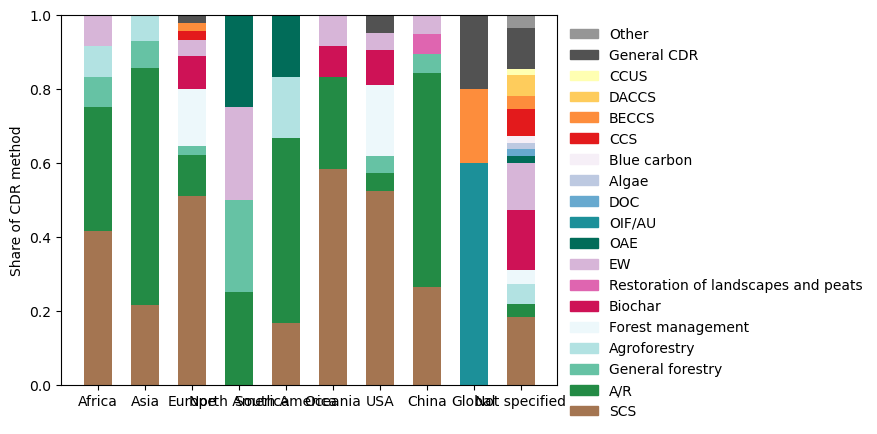

In [62]:
fig, ax = plt.subplots()
cdr_methods = list(cdr_method_colors.keys())

prev_values = np.zeros(len(loc_meth.loc[loc_meth["CDR_method"]==cdr_methods[0]]))
for i, f in enumerate(cdr_methods):
    #print(topic)
    ax.bar(location_order, loc_meth.loc[loc_meth["CDR_method"]==f,"rel"], 
              width, bottom=prev_values, 
              label=f,
              color=loc_meth.loc[loc_meth["CDR_method"]==f,"col"])
    prev_values += np.array(loc_meth.loc[loc_meth["CDR_method"]==f,"rel"])

legend_group = []
for c in reversed(cdr_methods):
    legend_group.append(mpatches.Patch(color=cdr_method_colors[c], label=c))    
leg_gr = plt.legend(handles=legend_group, bbox_to_anchor=(1.,1), fontsize=10, frameon=False,ncol=1)
    
ax.set_ylabel('Share of CDR method')

In [47]:
loc_meth_counts = df_quant_CDRex.groupby(['Study location', 'CDR_method']).size().reset_index(name='count')

loc_meth_counts['col'] = loc_meth_counts['CDR_method'].map(cdr_method_colors)

cdr_location_counts = df_quant_CDRex.groupby(['Study location', 'CDR_method']).size().unstack(fill_value=0)
#cdr_location_counts

#### All together: Final version of Figure 7

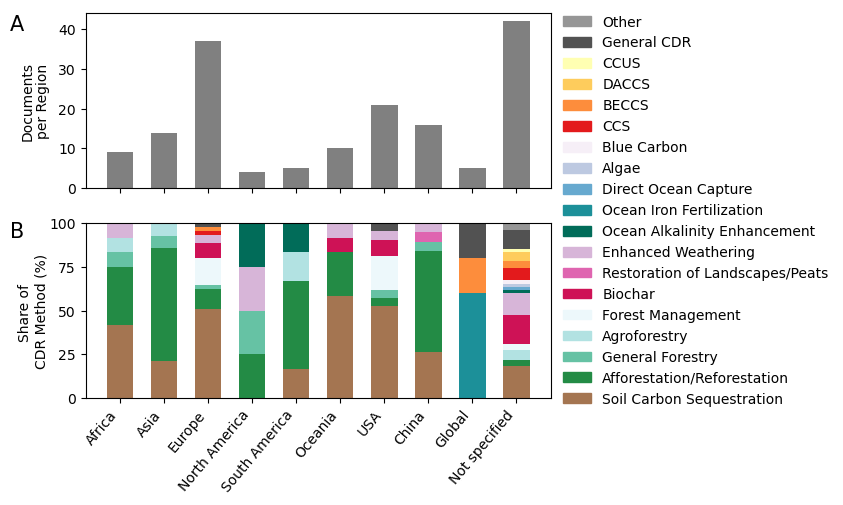

In [48]:
fig, ax = plt.subplots(2,1,figsize=(6,5), sharex=True)
width=0.6

##### absolute numbers
ax[0].bar(loc_size["Study location_continent"], loc_size["total_size"], width, color="grey")
ax[0].set_ylabel("Documents\nper Region")
ax[0].yaxis.set_label_coords(-0.0758, 0.5)  

##### CDR groups
prev_values = np.zeros(len(loc_meth.loc[loc_meth["CDR_method"]==cdr_methods[0]]))
for i, f in enumerate(cdr_methods):
    #print(topic)
    ax[1].bar(location_order, loc_meth.loc[loc_meth["CDR_method"]==f,"rel"], 
              width, bottom=prev_values, 
              label=f,
              color=loc_meth.loc[loc_meth["CDR_method"]==f,"col"])
    prev_values += np.array(loc_meth.loc[loc_meth["CDR_method"]==f,"rel"])

legend_group = []
for c in reversed(cdr_methods):
    legend_group.append(mpatches.Patch(color=cdr_method_colors[c], label=cdr_method_label[c]))    
leg_gr = ax[1].legend(handles=legend_group, bbox_to_anchor=(1.,2.26), fontsize=10, frameon=False,ncol=1)
    
ax[1].set_ylabel("Share of \nCDR Method (%)")
ax[1].yaxis.set_label_coords(-0.08, 0.5)  
ax[1].set_yticks([0,0.25,0.5,0.75,1],[0,25,50,75,100])
_=ax[1].set_xticks([i for i in range(len(location_order))], location_order, rotation=50, ha="right")

plt.text(-2.5,2.1,"A",fontsize=15)
plt.text(-2.5,0.92,"B",fontsize=15)


fig.savefig('Fig7_final.png', bbox_inches="tight", facecolor='white', edgecolor='none')